# Process 1 – Sterilization Simulation Explorer

Use this notebook to inspect and correct the simulation output.
Re-run `generate_process_1.py` after tuning parameters in that file, then re-run this notebook.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pm4py
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_vis

DATA_DIR = Path('..') / 'data' / 'gold' / 'experiment_1' / 'process_1' / 'datasets'

df_event_log      = pd.read_parquet(DATA_DIR / 'df_event_log.parquet')
df_expanded       = pd.read_parquet(DATA_DIR / 'df_expanded.parquet')
df_production_plan = pd.read_parquet(DATA_DIR / 'df_production_plan.parquet')

print('Event log:       ', df_event_log.shape)
print('Expanded:        ', df_expanded.shape)
print('Production plan: ', df_production_plan.shape)

Event log:        (1680, 8)
Expanded:         (8396, 17)
Production plan:  (120, 5)


## 1. Event log overview

In [2]:
print('Columns:', df_event_log.dtypes.to_dict())
df_event_log.head(14)

Columns: {'case_id': dtype('O'), 'activity': dtype('O'), 'timestamp_start': dtype('<M8[ns]'), 'timestamp_end': dtype('<M8[ns]'), 'higher_level_activity': dtype('O'), 'object_type': dtype('O'), 'object': dtype('O'), 'object_attributes': dtype('O')}


,case_id,activity,timestamp_start,timestamp_end,higher_level_activity,object_type,object,object_attributes
0,batch_001,prepare,2024-01-15 00:00:00.000000,2024-01-15 00:00:05.559925,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 463.3}"
1,batch_001,working,2024-01-15 00:00:06.559925,2024-01-15 00:01:13.906558,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 463.3}"
2,batch_001,heat,2024-01-15 00:01:14.906558,2024-01-15 00:01:47.615250,Destillation,sterilization_line,destillation,"{'recipe': 'standard', 'volume_L': 463.3}"
3,batch_001,prepare,2024-01-15 00:01:48.615250,2024-01-15 00:01:54.175175,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
4,batch_001,working,2024-01-15 00:01:55.175175,2024-01-15 00:02:32.664783,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
5,batch_001,cool,2024-01-15 00:02:33.664783,2024-01-15 00:02:39.224708,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
6,batch_001,prepare,2024-01-15 00:02:40.224708,2024-01-15 00:04:40.184385,Autoclaving,sterilization_line,autoclaving_1,"{'recipe': 'standard', 'volume_L': 463.3}"
7,batch_001,heat,2024-01-15 00:04:41.184385,2024-01-15 00:22:22.758636,Autoclaving,sterilization_line,autoclaving_1,"{'recipe': 'standard', 'volume_L': 463.3}"
8,batch_002,prepare,2024-01-15 00:15:00.000000,2024-01-15 00:15:02.859484,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 238.3}"
9,batch_002,working,2024-01-15 00:15:03.859484,2024-01-15 00:15:38.156163,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 238.3}"


In [3]:
# Activity counts per station
(
    df_event_log
    .groupby(['higher_level_activity', 'activity'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['higher_level_activity', 'activity'])
)

,higher_level_activity,activity,count
0,Autoclaving,cool,120
1,Autoclaving,heat,120
2,Autoclaving,hold,120
3,Autoclaving,prepare,120
4,Bottling,cool,120
5,Bottling,prepare,120
6,Bottling,working,120
7,Destillation,heat,120
8,Packaging,prepare,120
9,Packaging,working,120


## 2. pm4py Directly-Follows Graph (DFG)

### 2a. Activity-level DFG

In [4]:
import tempfile, os
from IPython.display import Image

# Convert to pm4py event log format
el_pm4py = df_event_log.rename(columns={
    'case_id':         'case:concept:name',
    'activity':        'concept:name',
    'timestamp_start': 'time:timestamp',
})
el_pm4py['time:timestamp'] = pd.to_datetime(el_pm4py['time:timestamp'])

log = pm4py.convert_to_event_log(el_pm4py)

dfg, start_acts, end_acts = pm4py.discover_dfg(log)

gviz = dfg_vis.apply(
    dfg, log=log, variant=dfg_vis.Variants.FREQUENCY,
    parameters={'start_activities': start_acts, 'end_activities': end_acts}
)
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
    dfg_vis.save(gviz, f.name)
    Image(f.name)

### 2b. Station-level DFG  (higher_level_activity)

In [5]:
# Use first event per (case_id, station) as the station-level trace
station_log = (
    df_event_log
    .sort_values('timestamp_start')
    .groupby(['case_id', 'higher_level_activity'], sort=False)
    .first()
    .reset_index()
    .rename(columns={
        'case_id':               'case:concept:name',
        'higher_level_activity': 'concept:name',
        'timestamp_start':       'time:timestamp',
    })
)
station_log['time:timestamp'] = pd.to_datetime(station_log['time:timestamp'])

log_station = pm4py.convert_to_event_log(station_log)
dfg_s, sa_s, ea_s = pm4py.discover_dfg(log_station)

gviz_s = dfg_vis.apply(
    dfg_s, log=log_station, variant=dfg_vis.Variants.FREQUENCY,
    parameters={'start_activities': sa_s, 'end_activities': ea_s}
)
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
    dfg_vis.save(gviz_s, f.name)
    Image(f.name)

## 3. Process model – Inductive Miner (Petri net)

Petri nets discovered with the **Inductive Miner** give you a formal model of the control flow. A green square = source place (start), a red square = sink place (end), rounded boxes = transitions (activities).

### 3a. Activity-level Petri net

In [ ]:
from pm4py.visualization.petri_net import visualizer as pn_vis

# Discover Petri net from the activity-level log (reuse 'log' from cell 2a)
net_a, im_a, fm_a = pm4py.discover_petri_net_inductive(log)

gviz_pn_a = pn_vis.apply(
    net_a, im_a, fm_a,
    variant=pn_vis.Variants.FREQUENCY,
    parameters={'log': log}
)
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
    pn_vis.save(gviz_pn_a, f.name)
    Image(f.name)

### 3b. Station-level Petri net

In [ ]:
# Discover Petri net from the station-level log (reuse 'log_station' from cell 2b)
net_s, im_s, fm_s = pm4py.discover_petri_net_inductive(log_station)

gviz_pn_s = pn_vis.apply(
    net_s, im_s, fm_s,
    variant=pn_vis.Variants.FREQUENCY,
    parameters={'log': log_station}
)
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
    pn_vis.save(gviz_pn_s, f.name)
    Image(f.name)

## 3. Duration distributions per station / activity

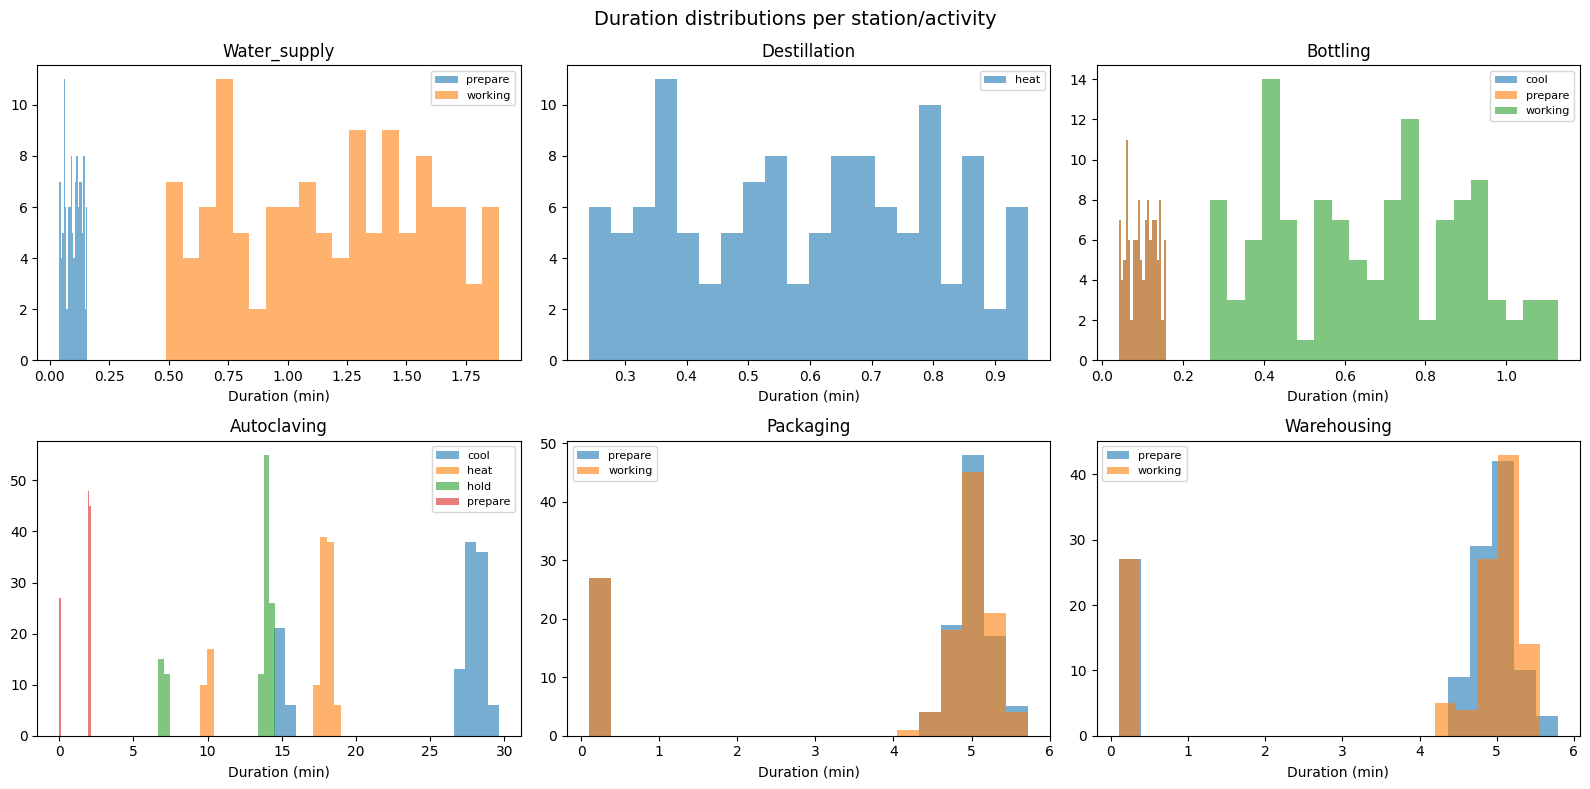

In [6]:
df_event_log['duration_min'] = (
    (df_event_log['timestamp_end'] - df_event_log['timestamp_start'])
    .dt.total_seconds() / 60
)

stations = df_event_log['higher_level_activity'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, station in zip(axes, stations):
    sub = df_event_log[df_event_log['higher_level_activity'] == station]
    for act, grp in sub.groupby('activity'):
        ax.hist(grp['duration_min'], bins=20, alpha=0.6, label=act)
    ax.set_title(station)
    ax.set_xlabel('Duration (min)')
    ax.legend(fontsize=8)

plt.suptitle('Duration distributions per station/activity', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Gantt chart – batch timeline (first 20 batches)

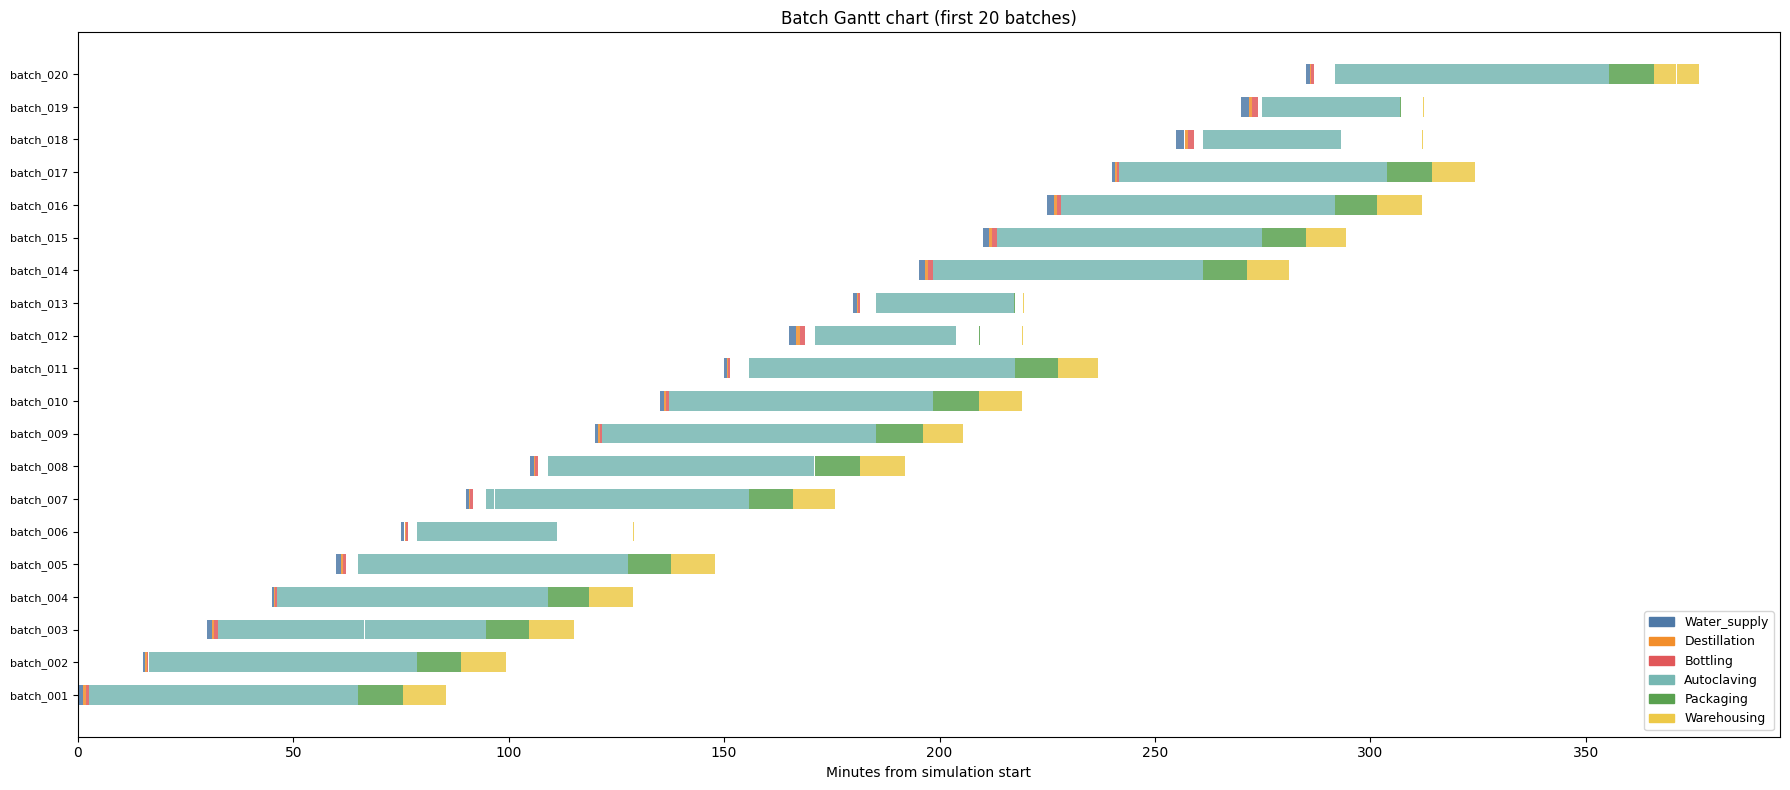

In [7]:
N_GANTT = 20
batches = df_event_log['case_id'].unique()[:N_GANTT]

STATION_COLORS = {
    'Water_supply':  '#4e79a7',
    'Destillation':  '#f28e2b',
    'Bottling':      '#e15759',
    'Autoclaving':   '#76b7b2',
    'Packaging':     '#59a14f',
    'Warehousing':   '#edc948',
}

fig, ax = plt.subplots(figsize=(18, 8))
t0 = df_event_log['timestamp_start'].min()

for yi, bid in enumerate(batches):
    sub = df_event_log[df_event_log['case_id'] == bid]
    for _, row in sub.iterrows():
        start = (row['timestamp_start'] - t0).total_seconds() / 60
        dur   = (row['timestamp_end']   - row['timestamp_start']).total_seconds() / 60
        color = STATION_COLORS.get(row['higher_level_activity'], 'grey')
        ax.barh(yi, dur, left=start, height=0.6, color=color, alpha=0.85)

ax.set_yticks(range(N_GANTT))
ax.set_yticklabels(batches, fontsize=8)
ax.set_xlabel('Minutes from simulation start')
ax.set_title('Batch Gantt chart (first 20 batches)')
patches = [mpatches.Patch(color=c, label=s) for s, c in STATION_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Energy curves – sample batches

Each subplot shows one energy sensor over time, colored by activity.

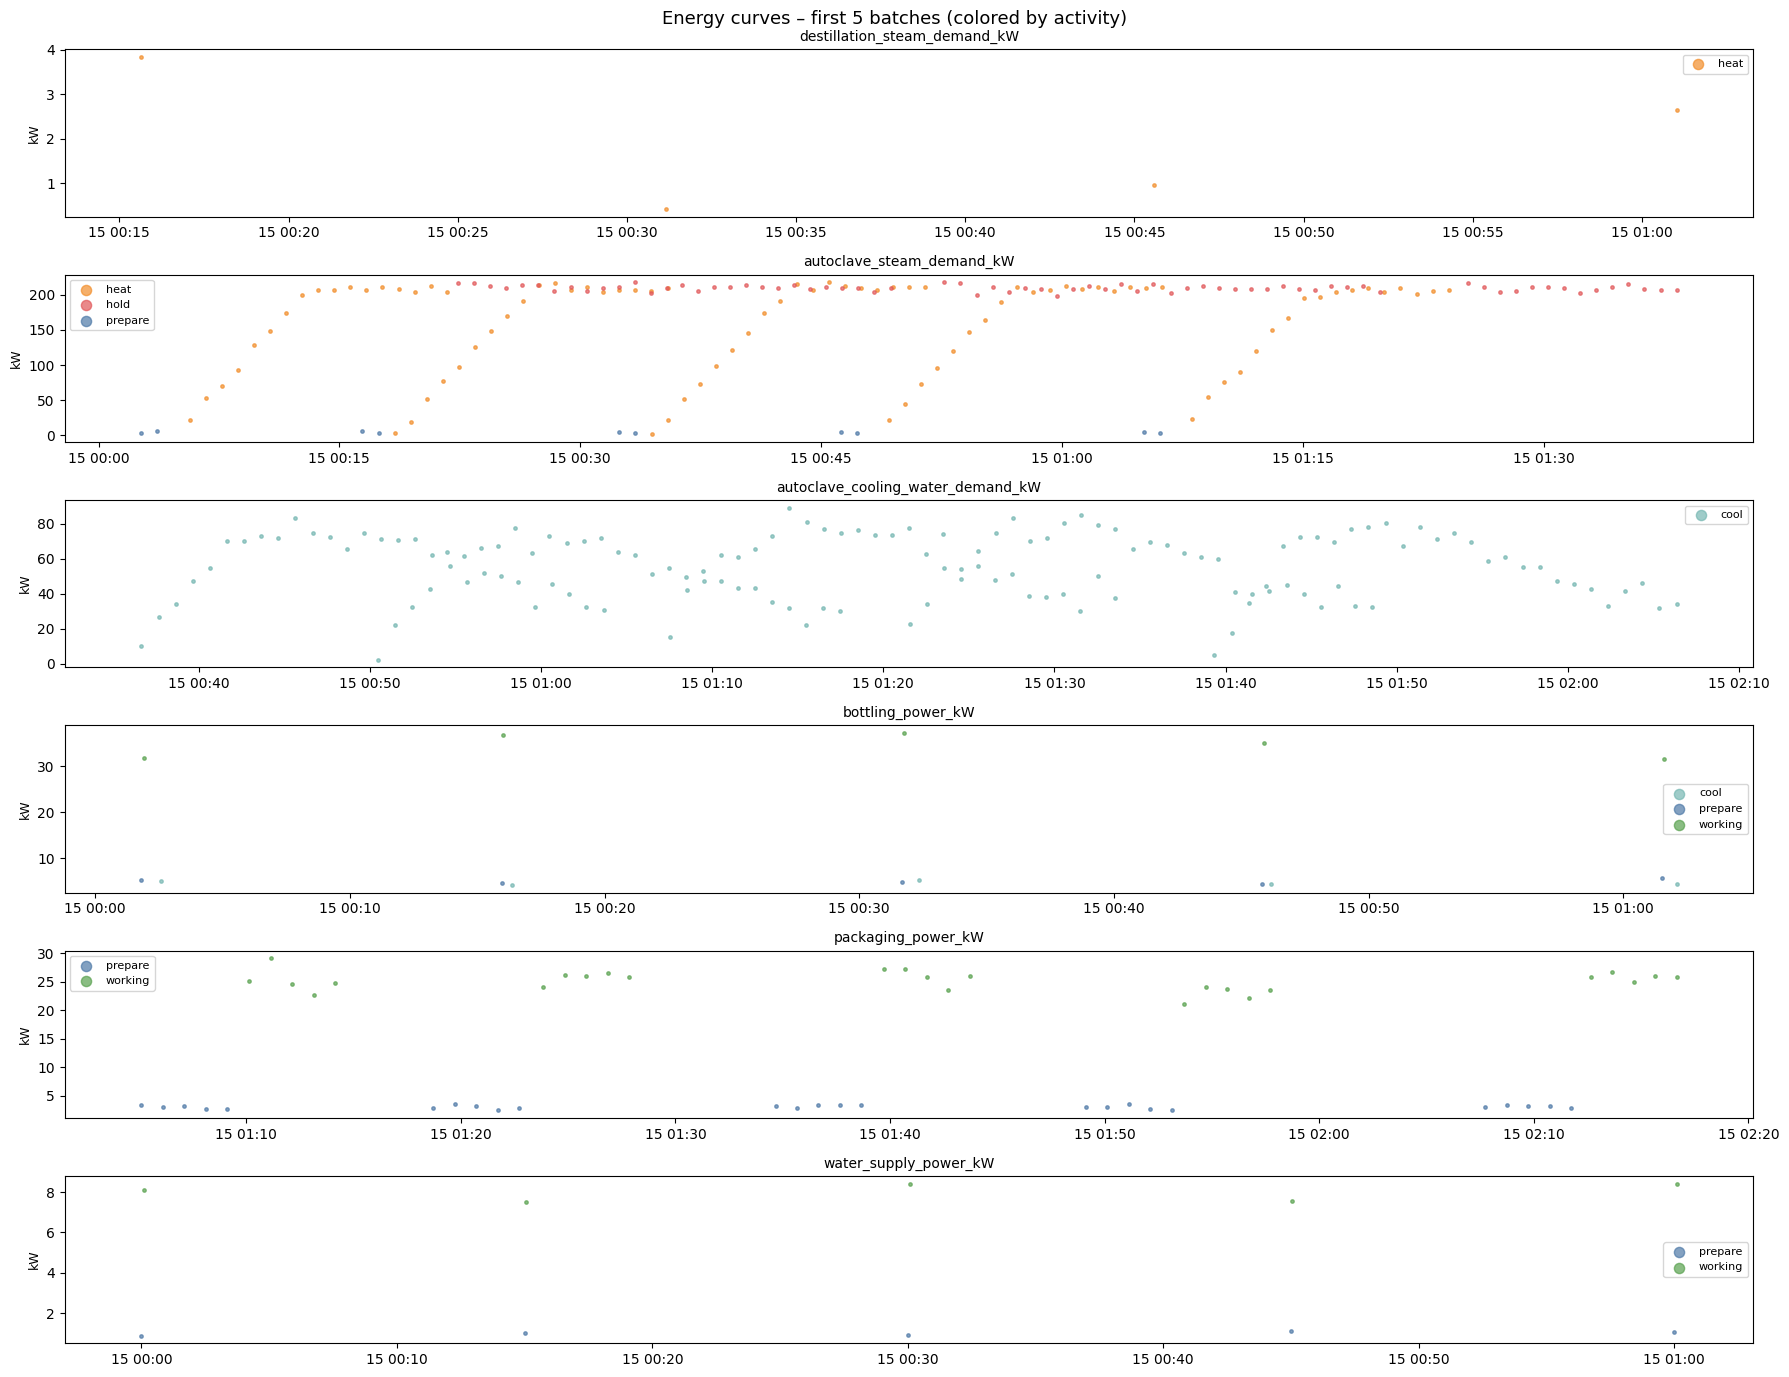

In [8]:
ENERGY_SENSORS = [
    'destillation_steam_demand_kW_energy',
    'autoclave_steam_demand_kW_energy',
    'autoclave_cooling_water_demand_kW_energy',
    'bottling_power_kW_energy',
    'packaging_power_kW_energy',
    'water_supply_power_kW_energy',
]

ACTIVITY_COLORS = {
    'prepare': '#4e79a7',
    'heat':    '#f28e2b',
    'hold':    '#e15759',
    'cool':    '#76b7b2',
    'working': '#59a14f',
}

# Show first 5 batches for clarity
SAMPLE_BATCHES = df_event_log['case_id'].unique()[:5]
sub_exp = df_expanded[df_expanded['case_id_log'].isin(SAMPLE_BATCHES)].copy()

fig, axes = plt.subplots(len(ENERGY_SENSORS), 1, figsize=(18, 14), sharex=False)

for ax, sensor in zip(axes, ENERGY_SENSORS):
    active = sub_exp[sub_exp[sensor] > 0].copy()
    if active.empty:
        ax.set_title(sensor + ' — no data')
        continue
    for act, grp in active.groupby('activity_log'):
        color = ACTIVITY_COLORS.get(act, 'grey')
        ax.scatter(grp['datetime_energy'], grp[sensor],
                   s=6, color=color, alpha=0.7, label=act)
    ax.set_ylabel('kW', fontsize=9)
    ax.set_title(sensor.replace('_energy', ''), fontsize=10)
    ax.legend(fontsize=8, markerscale=3)

plt.suptitle('Energy curves – first 5 batches (colored by activity)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Weather vs. energy – verifying physical relationships

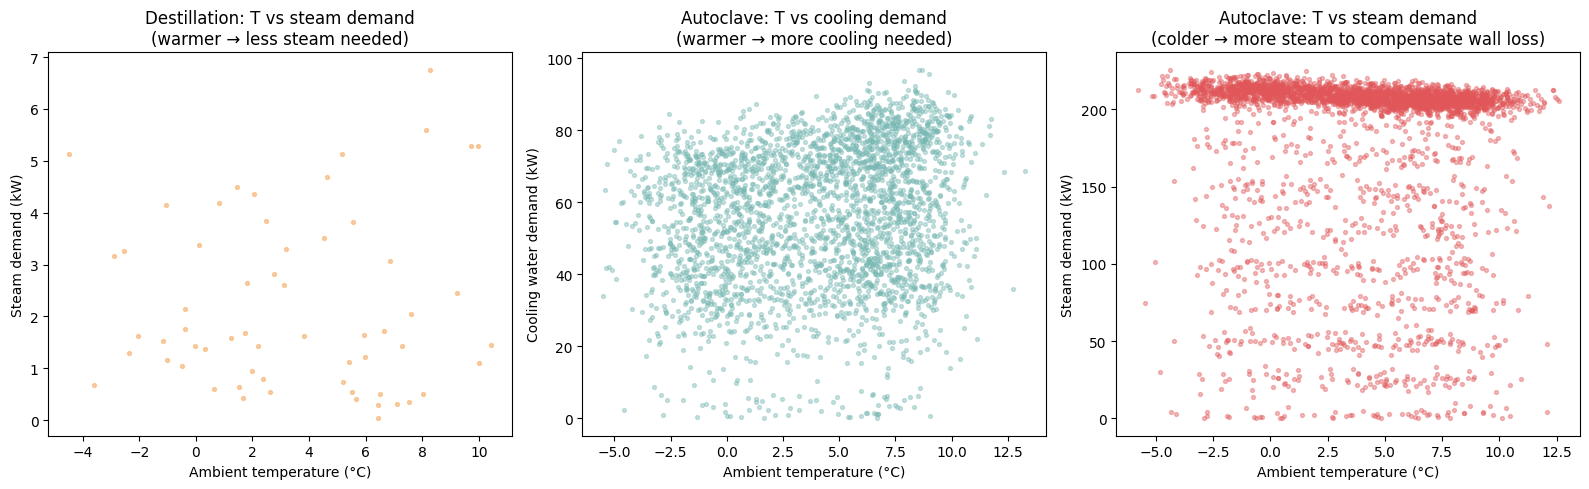

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a. Temperature vs. distillation steam demand
dest = df_expanded[df_expanded['destillation_steam_demand_kW_energy'] > 0]
axes[0].scatter(dest['ef_temperature_2m_energy'],
                dest['destillation_steam_demand_kW_energy'],
                s=8, alpha=0.4, color='#f28e2b')
axes[0].set_xlabel('Ambient temperature (°C)')
axes[0].set_ylabel('Steam demand (kW)')
axes[0].set_title('Destillation: T vs steam demand\n(warmer → less steam needed)')

# 6b. Temperature vs. autoclave cooling water demand (cool phase only)
cool = df_expanded[
    (df_expanded['autoclave_cooling_water_demand_kW_energy'] > 0) &
    (df_expanded['activity_log'] == 'cool')
]
axes[1].scatter(cool['ef_temperature_2m_energy'],
                cool['autoclave_cooling_water_demand_kW_energy'],
                s=8, alpha=0.4, color='#76b7b2')
axes[1].set_xlabel('Ambient temperature (°C)')
axes[1].set_ylabel('Cooling water demand (kW)')
axes[1].set_title('Autoclave: T vs cooling demand\n(warmer → more cooling needed)')

# 6c. Temperature vs. autoclave steam demand (heat + hold)
steam = df_expanded[
    (df_expanded['autoclave_steam_demand_kW_energy'] > 0) &
    (df_expanded['activity_log'].isin(['heat', 'hold']))
]
axes[2].scatter(steam['ef_temperature_2m_energy'],
                steam['autoclave_steam_demand_kW_energy'],
                s=8, alpha=0.4, color='#e15759')
axes[2].set_xlabel('Ambient temperature (°C)')
axes[2].set_ylabel('Steam demand (kW)')
axes[2].set_title('Autoclave: T vs steam demand\n(colder → more steam to compensate wall loss)')

plt.tight_layout()
plt.show()

## 7. Weather time series over the simulation period

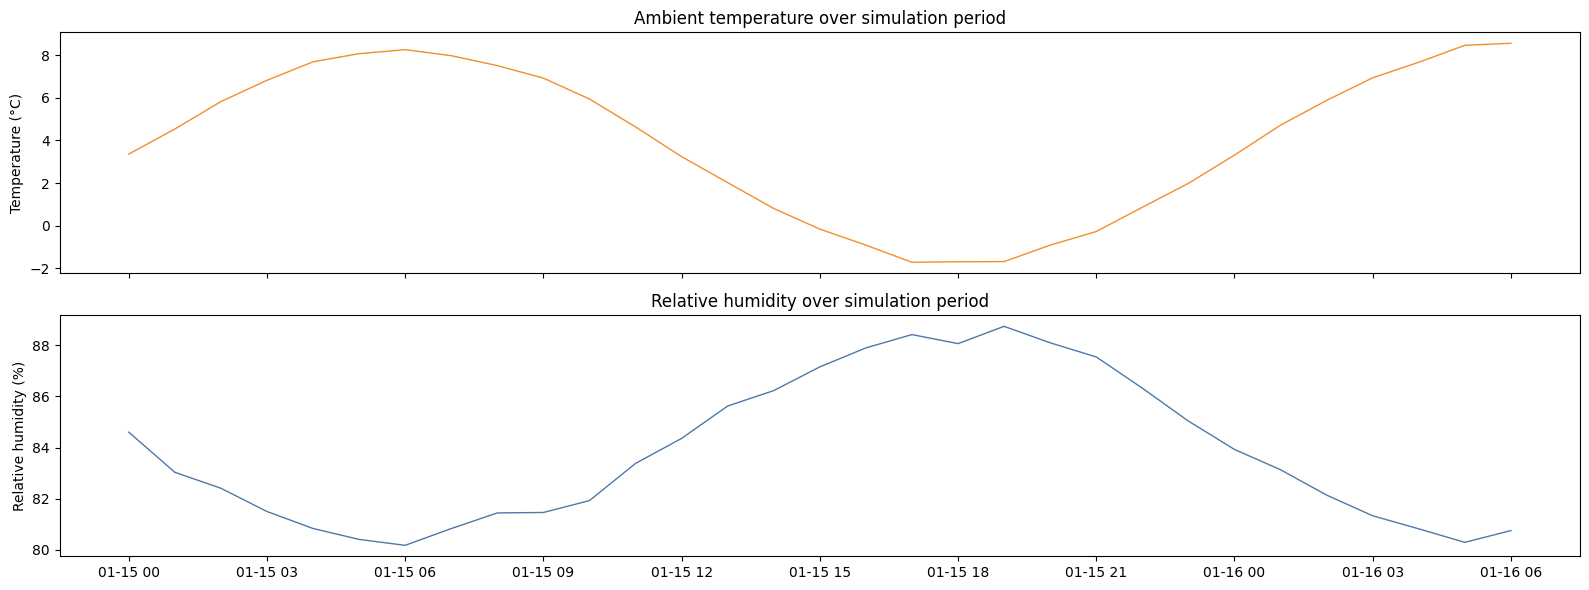

In [10]:
weather = (
    df_expanded
    .set_index('datetime_energy')[['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy']]
    .resample('1h').mean()
    .dropna()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

ax1.plot(weather.index, weather['ef_temperature_2m_energy'], color='#f28e2b', lw=1)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Ambient temperature over simulation period')

ax2.plot(weather.index, weather['ef_relative_humidity_2m_energy'], color='#4e79a7', lw=1)
ax2.set_ylabel('Relative humidity (%)')
ax2.set_title('Relative humidity over simulation period')

plt.tight_layout()
plt.show()

## 8. Autoclave load – how many autoclave resources run in parallel

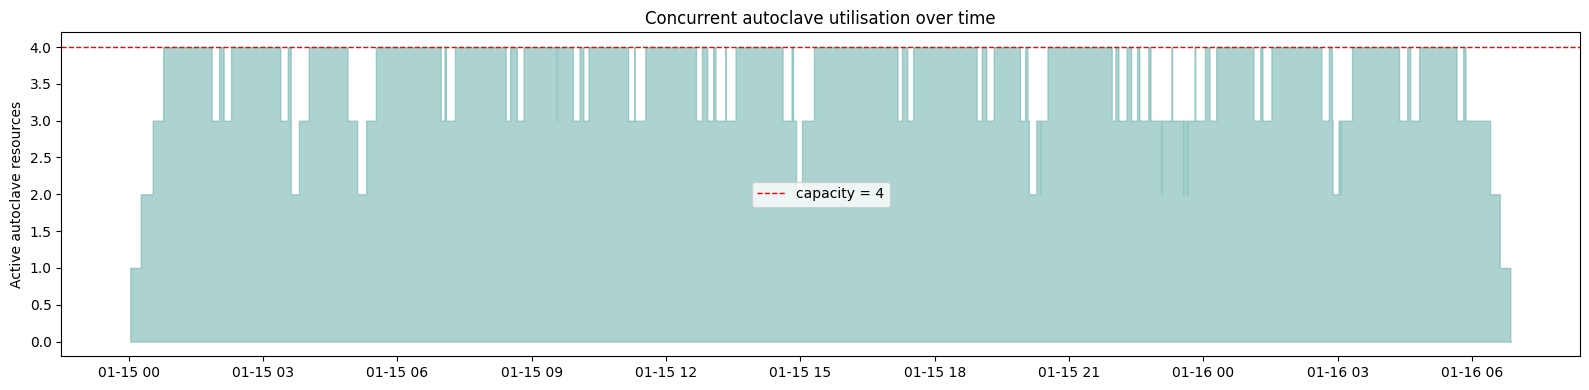

In [11]:
ac_events = df_event_log[df_event_log['higher_level_activity'] == 'Autoclaving'].copy()

# Build 1-minute timeline of concurrent autoclave usage
t_min = ac_events['timestamp_start'].min().floor('min')
t_max = ac_events['timestamp_end'].max().ceil('min')
timeline = pd.date_range(t_min, t_max, freq='min')

concurrent = np.zeros(len(timeline))
for _, row in ac_events.iterrows():
    mask = (timeline >= row['timestamp_start']) & (timeline < row['timestamp_end'])
    concurrent[mask] += 1

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(timeline, concurrent, step='pre', alpha=0.6, color='#76b7b2')
ax.set_ylabel('Active autoclave resources')
ax.set_title('Concurrent autoclave utilisation over time')
ax.axhline(4, color='red', linestyle='--', lw=1, label='capacity = 4')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Expanded dataset overview

In [12]:
df_expanded.head(5)

,datetime_energy,ef_temperature_2m_energy,ef_relative_humidity_2m_energy,destillation_steam_demand_kW_energy,autoclave_steam_demand_kW_energy,autoclave_cooling_water_demand_kW_energy,bottling_power_kW_energy,packaging_power_kW_energy,water_supply_power_kW_energy,timestamp_start_log,timestamp_end_log,activity_log,higher_level_activity_log,object_type_log,object_log,case_id_log,object_attributes_log
0,2024-01-15 00:00:00.000000,1.941789,75.487378,0.0,0.0,0.0,0.000000,0.0,0.882894,2024-01-15 00:00:00.000000,2024-01-15 00:00:05.559925,prepare,Water_supply,sterilization_line,water_supply,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
1,2024-01-15 00:00:06.559925,2.129406,91.428965,0.0,0.0,0.0,0.000000,0.0,8.102866,2024-01-15 00:00:06.559925,2024-01-15 00:01:13.906558,working,Water_supply,sterilization_line,water_supply,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
2,2024-01-15 00:01:14.906558,2.769762,80.791063,0.0,0.0,0.0,0.000000,0.0,0.000000,2024-01-15 00:01:14.906558,2024-01-15 00:01:47.615250,heat,Destillation,sterilization_line,destillation,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
3,2024-01-15 00:01:48.615250,2.765596,83.017738,0.0,0.0,0.0,5.292771,0.0,0.000000,2024-01-15 00:01:48.615250,2024-01-15 00:01:54.175175,prepare,Bottling,sterilization_line,bottling,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
4,2024-01-15 00:01:55.175175,3.854121,73.527360,0.0,0.0,0.0,31.864168,0.0,0.000000,2024-01-15 00:01:55.175175,2024-01-15 00:02:32.664783,working,Bottling,sterilization_line,bottling,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"


In [13]:
# Summary stats for energy sensors
sensors = [
    'destillation_steam_demand_kW_energy',
    'autoclave_steam_demand_kW_energy',
    'autoclave_cooling_water_demand_kW_energy',
    'bottling_power_kW_energy',
    'packaging_power_kW_energy',
    'water_supply_power_kW_energy',
]
# Only non-zero rows per sensor
summary = {}
for s in sensors:
    d = df_expanded[df_expanded[s] > 0][s]
    summary[s] = {'n_rows': len(d), 'mean': d.mean(), 'std': d.std(),
                  'min': d.min(), 'max': d.max()}
pd.DataFrame(summary).T.round(2)

,n_rows,mean,std,min,max
destillation_steam_demand_kW_energy,60.0,2.21,1.67,0.04,6.76
autoclave_steam_demand_kW_energy,3592.0,170.07,68.43,0.01,225.68
autoclave_cooling_water_demand_kW_energy,2954.0,56.43,19.21,0.03,96.80
bottling_power_kW_energy,360.0,15.01,14.27,3.89,39.56
packaging_power_kW_energy,984.0,14.00,11.07,2.09,29.73
water_supply_power_kW_energy,273.0,4.92,3.51,0.59,9.55
